# Сентимент-анализ русскоязычных текстов: LSTM, GRU, FCNN и Optuna

В этом блокноте мы строим полный исследовательский пайплайн для задачи **классификации сентимента** на датасете `sepidmnorozy/Russian_sentiment`.

Задача сентимент-анализа состоит в том, чтобы по тексту $x$ предсказать класс эмоциональной окраски $y$:

$$
f_\theta(x) \rightarrow y,
$$

где $f_\theta$ — модель с параметрами $\theta$, а $y$ — метка класса.

В блокноте будут три семейства моделей:

- **FCNN** — полносвязная нейронная сеть поверх усредненных эмбеддингов токенов.
- **LSTM** — рекуррентная модель с долговременной памятью.
- **GRU** — более компактная рекуррентная модель с воротами обновления и сброса.

После базовых экспериментов мы используем **Optuna** для подбора гиперпараметров: числа слоев, числа нейронов, learning rate, dropout и batch normalization.

## 1. Импорты и глобальные настройки

Глобальные константы в начале блокнота нужны для воспроизводимости и удобного управления экспериментами.

- `EPOCHS = 20` — максимальное число эпох обучения одной модели.
- `BATCH_SIZE = 64` — число объектов, которое модель видит за один шаг оптимизации.
- `MAX_LEN` — максимальная длина последовательности токенов после токенизации.
- `RANDOM_STATE` — seed для воспроизводимости разбиений и инициализаций.

В реальном исследовании `MAX_LEN` выбирают после анализа распределения длин текстов.

In [1]:
# Базовые библиотеки для работы с таблицами, массивами и графиками.
import gc
import random
import warnings
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Метрики и вспомогательные инструменты из scikit-learn.
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

# Hugging Face Datasets загружает учебный датасет.
from datasets import load_dataset

# Hugging Face Transformers предоставляет токенизатор RuBERT-tiny2.
from transformers import AutoTokenizer

# TensorFlow/Keras используется для построения LSTM, GRU и FCNN.
import tensorflow as tf

# Optuna отвечает за автоматический подбор гиперпараметров.
import optuna

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Глобальные константы эксперимента
# ------------------------------------------------------------
EPOCHS = 20
BATCH_SIZE = 64
MAX_LEN = 1024
RANDOM_STATE = 42
N_TRIALS = 100
TOKENIZER_NAME = "cointegrated/rubert-tiny2"
DATASET_NAME = "sepidmnorozy/Russian_sentiment"

# Делаем результаты более воспроизводимыми.
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1779181415.082115   41705 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779181415.113298   41705 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779181415.769834   41705 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1779181416.229374   41705 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 2. Постановка задачи и функция потерь

Для бинарной классификации модель обычно возвращает вероятность положительного класса:

$$
\hat{p} = P(y=1 \mid x).
$$

Тогда используется бинарная кросс-энтропия:

$$
\mathcal{L}_{BCE} = -\frac{1}{N}\sum_{i=1}^{N} \left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right].
$$

Для многоклассовой классификации модель возвращает вектор вероятностей:

$$
\hat{\mathbf{p}} = (\hat{p}_1, \hat{p}_2, \ldots, \hat{p}_K), \qquad \sum_{k=1}^{K}\hat{p}_k = 1.
$$

В этом случае используется sparse categorical cross-entropy:

$$
\mathcal{L}_{CE} = -\frac{1}{N}\sum_{i=1}^{N}\log \hat{p}_{i, y_i}.
$$

Код ниже автоматически выбирает тип выхода и функцию потерь по числу классов.

## 3. Загрузка датасета

Используем Hugging Face Datasets:

```python
ds = load_dataset("sepidmnorozy/Russian_sentiment")
```

Ожидаем разбиения `train`, `validation` и `test`, а также колонки `text` и `label`.

In [2]:
# Загружаем датасет из Hugging Face Hub.
# При первом запуске данные будут скачаны и сохранены в локальный кеш.
ds = load_dataset(DATASET_NAME)

ds

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 2938
    })
    validation: Dataset({
        features: ['label', 'text'],
        num_rows: 424
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 867
    })
})

In [3]:
# Переводим split-ы Hugging Face Dataset в pandas.DataFrame.
# Это удобно для первичного анализа, подсчета частот и просмотра примеров.
train_df = pd.DataFrame(ds["train"])
val_df = pd.DataFrame(ds["validation"])
test_df = pd.DataFrame(ds["test"])

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (2938, 2)
Validation: (424, 2)
Test: (867, 2)


,label,text
0,0,Досудебное расследование по факту покупки ЕНПФ...
1,0,Медики рассказали о состоянии пострадавшего му...
2,0,"Прошел почти год , как железнодорожным операто..."
3,0,По итогам 12 месяцев 2016 года на территории р...
4,0,Астана . 21 ноября . Kazakhstan Today - Агентс...


## 4. Первичный анализ данных

Перед обучением модели важно проверить названия колонок, типы данных, пропуски, баланс классов и длины текстов после токенизации.

Если классы несбалансированы, accuracy может быть обманчивой. Поэтому в NLP-задачах часто используют `F1-score`, особенно `macro F1`, который усредняет качество по классам.

Для класса $c$:

$$
Precision_c = \frac{TP_c}{TP_c + FP_c}, \qquad
Recall_c = \frac{TP_c}{TP_c + FN_c}.
$$

$$
F1_c = 2 \cdot \frac{Precision_c \cdot Recall_c}{Precision_c + Recall_c}.
$$

In [4]:
# Смотрим структуру таблиц и наличие пропусков.
print("Колонки:", train_df.columns.tolist())
print("Типы данных:")
print(train_df.dtypes)
print("Пропуски в train:")
print(train_df.isna().sum())

Колонки: ['label', 'text']
Типы данных:
label    int64
text       str
dtype: object
Пропуски в train:
label    0
text     0
dtype: int64


In [5]:
# Удаляем строки с пропущенными текстами или метками, если такие есть.
# copy() используется, чтобы последующие изменения не вызывали предупреждения pandas.
train_df = train_df.dropna(subset=["text", "label"]).copy()
val_df = val_df.dropna(subset=["text", "label"]).copy()
test_df = test_df.dropna(subset=["text", "label"]).copy()

# Приводим текст к строковому типу: это защищает токенизатор от неожиданных типов.
train_df["text"] = train_df["text"].astype(str)
val_df["text"] = val_df["text"].astype(str)
test_df["text"] = test_df["text"].astype(str)

print("Размеры после удаления пропусков:")
print(train_df.shape, val_df.shape, test_df.shape)

Размеры после удаления пропусков:
(2938, 2) (424, 2) (867, 2)


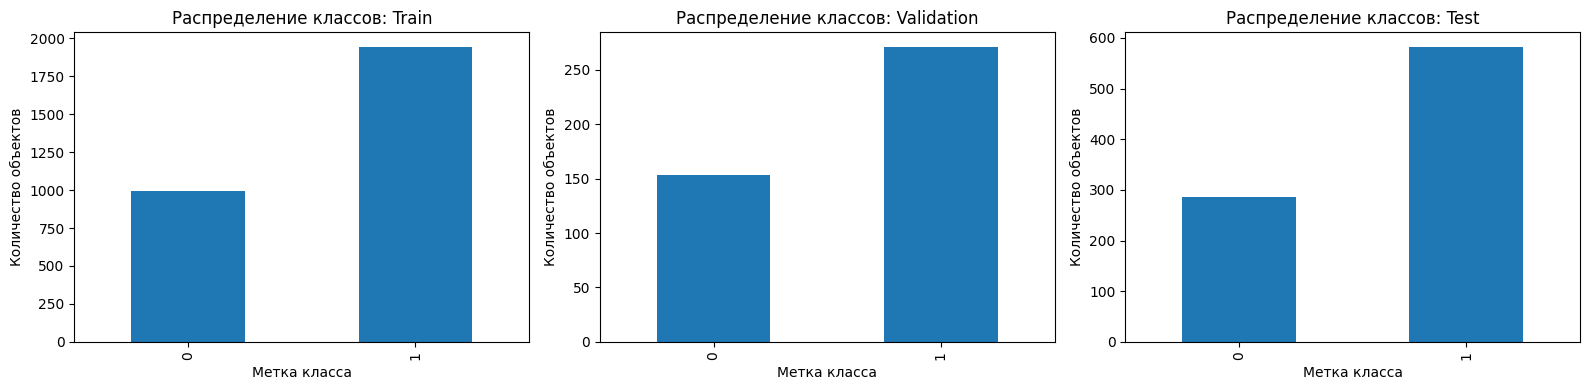

In [6]:
# Анализируем распределение классов.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, frame, title in zip(
    axes,
    [train_df, val_df, test_df],
    ["Train", "Validation", "Test"],
):
    counts = frame["label"].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax)
    ax.set_title(f"Распределение классов: {title}")
    ax.set_xlabel("Метка класса")
    ax.set_ylabel("Количество объектов")

plt.tight_layout()
plt.show()

## 5. Токенизация русскоязычного текста

Нейронная сеть не работает напрямую со строками. Сначала текст переводится в последовательность токенов, а затем токены заменяются числовыми идентификаторами:

$$
[t_1, t_2, \ldots, t_m] \rightarrow [id_1, id_2, \ldots, id_m].
$$

Мы используем токенизатор `cointegrated/rubert-tiny2`. В этом блокноте мы используем **только токенизатор**, а не предобученный трансформер. Эмбеддинги обучаются с нуля внутри Keras-моделей.

In [7]:
# Загружаем самый легкий и быстрый токенизатор для русскоязычных текстов.
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

example_text = "Я хочу обучить модель сентимента для русскоязычных отзывов"
example_tokens = tokenizer.tokenize(example_text)
example_ids = tokenizer.encode(example_text, add_special_tokens=True)

print("Текст:", example_text)
print("Токены:", example_tokens)
print("ID токенов:", example_ids)
print("Размер словаря токенизатора:", len(tokenizer))

Текст: Я хочу обучить модель сентимента для русскоязычных отзывов
Токены: ['Я', 'хочу', 'обучить', 'модель', 'сентимента', 'для', 'русскоязычных', 'отзывов']
ID токенов: [2, 311, 30473, 79366, 13246, 69823, 871, 65705, 40451, 3]
Размер словаря токенизатора: 83828


In [8]:
def count_tokens(text: str, tokenizer: AutoTokenizer) -> int:
    """
    Считает число токенов в одном тексте.

    Параметры:
    text : str
        Исходный текстовый документ.
    tokenizer : AutoTokenizer
        Токенизатор Hugging Face, который переводит текст в токены и token id.

    Возвращает:
    int
        Количество token id с учетом специальных токенов [CLS]/[SEP], если они есть у токенизатора.
    """
    return len(tokenizer.encode(text, add_special_tokens=True))

for frame in [train_df, val_df, test_df]:
    frame["token_count"] = frame["text"].apply(lambda x: count_tokens(x, tokenizer))

train_df["token_count"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (3472 > 2048). Running this sequence through the model will result in indexing errors


count     2938.000000
mean       729.893465
std       1944.666014
min          9.000000
50%        391.000000
75%        671.750000
90%       1387.600000
95%       2145.000000
99%       5669.520000
max      65787.000000
Name: token_count, dtype: float64

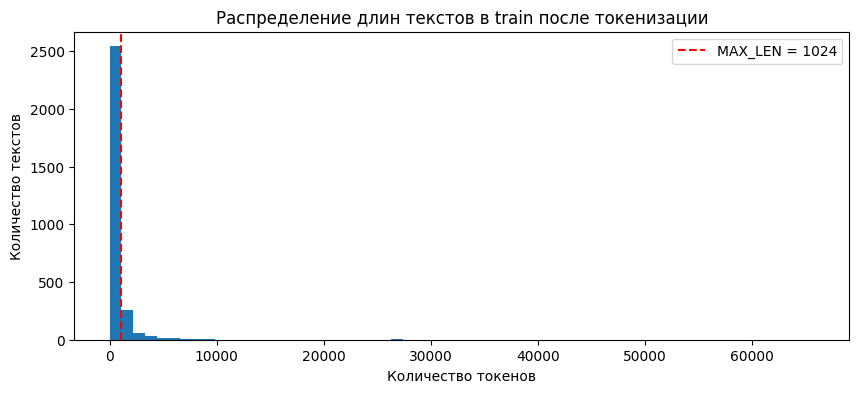

In [9]:
plt.figure(figsize=(10, 4))
plt.hist(train_df["token_count"], bins=60)
plt.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
plt.title("Распределение длин текстов в train после токенизации")
plt.xlabel("Количество токенов")
plt.ylabel("Количество текстов")
plt.legend()
plt.show()

## 6. Кодирование меток и подготовка массивов

Метки классов должны быть числами от `0` до `K-1`. Если исходные метки строковые, `LabelEncoder` создаст числовое представление.

Также мы превращаем тексты в матрицу размера:

$$
X \in \mathbb{N}^{N \times L},
$$

где $N$ — число текстов, а $L$ — `MAX_LEN`. Короткие тексты дополняются padding-токенами, длинные обрезаются.

In [10]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df["label"])
y_val = label_encoder.transform(val_df["label"])
y_test = label_encoder.transform(test_df["label"])

class_names = [str(x) for x in label_encoder.classes_]
NUM_CLASSES = len(class_names)

print("Классы:", class_names)
print("Количество классов:", NUM_CLASSES)
print("Форма y_train:", y_train.shape)

Классы: ['0', '1']
Количество классов: 2
Форма y_train: (2938,)


In [11]:
def tokenize_texts(texts: pd.Series, tokenizer: AutoTokenizer, max_len: int) -> Dict[str, np.ndarray]:
    """
    Токенизирует серию текстов и возвращает numpy-массивы.

    Параметры:
    texts : pd.Series
        Тексты, которые нужно перевести в token id.
    tokenizer : AutoTokenizer
        Токенизатор Hugging Face.
    max_len : int
        Фиксированная длина последовательности. Все тексты будут обрезаны или дополнены до нее.

    Возвращает:
    Dict[str, np.ndarray]
        Словарь с ключами input_ids и attention_mask.
    """
    return tokenizer(
        texts.tolist(), 
        max_length=max_len, 
        padding="max_length", 
        truncation=True, 
        return_tensors="np", 
        add_special_tokens=True
    )

train_encodings = tokenize_texts(train_df["text"], tokenizer, MAX_LEN)
val_encodings = tokenize_texts(val_df["text"], tokenizer, MAX_LEN)
test_encodings = tokenize_texts(test_df["text"], tokenizer, MAX_LEN)

print("X_train:", train_encodings["input_ids"].shape)
print("X_val:", val_encodings["input_ids"].shape)
print("X_test:", test_encodings["input_ids"].shape)

X_train: (2938, 1024)
X_val: (424, 1024)
X_test: (867, 1024)


In [12]:
def make_tf_dataset(encodings: Dict[str, np.ndarray], labels: np.ndarray, batch_size: int, shuffle: bool) -> tf.data.Dataset:
    """
    Создает tf.data.Dataset для эффективной подачи данных в Keras.

    Параметры:
    encodings : Dict[str, np.ndarray]
        Результат токенизации. Для наших моделей нужен input_ids.
    labels : np.ndarray
        Целевые метки классов.
    batch_size : int
        Размер батча.
    shuffle : bool
        Нужно ли перемешивать данные.
    """
    x = encodings["input_ids"].astype("int32")
    y = labels.astype("int32")
    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(y), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_tf_dataset(train_encodings, y_train, BATCH_SIZE, shuffle=True)
val_ds = make_tf_dataset(val_encodings, y_val, BATCH_SIZE, shuffle=False)
test_ds = make_tf_dataset(test_encodings, y_test, BATCH_SIZE, shuffle=False)

W0000 00:00:1779181426.351147   41705 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779181430.154828   41705 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a


## 7. Архитектуры моделей

Слой эмбеддингов переводит каждый token id в плотный вектор:

$$
Embedding(id_j) = \mathbf{e}_j \in \mathbb{R}^{d}.
$$

FCNN усредняет эмбеддинги по последовательности:

$$
\mathbf{h} = \frac{1}{L}\sum_{j=1}^{L}\mathbf{e}_j.
$$

LSTM использует ячейку памяти $c_t$ и ворота забывания/входа/выхода:

$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i), \quad f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f).
$$

GRU компактнее LSTM и использует update/reset gates:

$$
z_t = \sigma(W_z x_t + U_z h_{t-1}), \qquad r_t = \sigma(W_r x_t + U_r h_{t-1}).
$$

In [13]:
def get_output_layer(num_classes: int) -> Tuple[tf.keras.layers.Layer, str, List[str]]:
    """Возвращает выходной слой, функцию потерь и список метрик под число классов."""
    if num_classes == 2:
        return tf.keras.layers.Dense(1, activation="sigmoid", name="sentiment_probability"), "binary_crossentropy", ["accuracy"]
    return tf.keras.layers.Dense(num_classes, activation="softmax", name="class_probabilities"), "sparse_categorical_crossentropy", ["accuracy"]


def compile_model(model: tf.keras.Model, learning_rate: float, num_classes: int) -> tf.keras.Model:
    """
    Компилирует Keras-модель: задает optimizer, loss и метрики.

    learning_rate — шаг оптимизации Adam.
    num_classes — количество классов, нужно для выбора loss.
    """
    _, loss, metrics = get_output_layer(num_classes)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss=loss, metrics=metrics)
    return model

In [14]:
def build_fcnn_model(vocab_size: int, max_len: int, num_classes: int, embedding_dim: int = 128, dense_units: int = 128, num_dense_layers: int = 2, learning_rate: float = 3e-4, dropout: float = 0.3, batch_norm: bool = False) -> tf.keras.Model:
    """
    Строит FCNN-модель для классификации текста.

    vocab_size — размер словаря токенизатора.
    max_len — длина входной последовательности token id.
    num_classes — количество классов сентимента.
    embedding_dim — размерность обучаемого вектора токена.
    dense_units — количество нейронов в Dense-слое.
    num_dense_layers — количество полносвязных слоев после pooling.
    learning_rate — скорость обучения Adam.
    dropout — регуляризация, зануляющая часть признаков.
    batch_norm — добавлять ли BatchNormalization после Dense.
    """
    inputs = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
    x = tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True, name="token_embedding")(inputs)
    x = tf.keras.layers.GlobalAveragePooling1D(name="average_pooling")(x)
    for layer_idx in range(num_dense_layers):
        x = tf.keras.layers.Dense(dense_units, activation="relu", name=f"dense_{layer_idx + 1}")(x)
        if batch_norm:
            x = tf.keras.layers.BatchNormalization(name=f"batch_norm_{layer_idx + 1}")(x)
        x = tf.keras.layers.Dropout(dropout, name=f"dropout_{layer_idx + 1}")(x)
    output_layer, _, _ = get_output_layer(num_classes)
    model = tf.keras.Model(inputs=inputs, outputs=output_layer(x), name="FCNN_sentiment")
    return compile_model(model, learning_rate, num_classes)

In [15]:
def build_recurrent_model(cell_type: str, vocab_size: int, max_len: int, num_classes: int, embedding_dim: int = 128, rnn_units: int = 64, num_rnn_layers: int = 1, dense_units: int = 64, learning_rate: float = 3e-4, dropout: float = 0.3, recurrent_dropout: float = 0.0, batch_norm: bool = False, bidirectional: bool = True) -> tf.keras.Model:
    """
    Строит LSTM или GRU модель для классификации текста.

    cell_type — "LSTM" или "GRU".
    vocab_size — размер словаря токенизатора.
    max_len — фиксированная длина входной последовательности.
    num_classes — количество классов.
    embedding_dim — размерность эмбеддинга токена.
    rnn_units — количество скрытых единиц в рекуррентном слое.
    num_rnn_layers — сколько LSTM/GRU слоев ставим подряд.
    dense_units — число нейронов в Dense-проекции.
    learning_rate — скорость обучения Adam.
    dropout — dropout для входов и промежуточных представлений.
    recurrent_dropout — dropout внутри рекуррентного состояния.
    batch_norm — добавлять ли BatchNormalization.
    bidirectional — читать ли текст в двух направлениях.
    """
    normalized_cell_type = cell_type.upper()
    if normalized_cell_type not in {"LSTM", "GRU"}:
        raise ValueError("cell_type должен быть 'LSTM' или 'GRU'")
    rnn_layer_class = tf.keras.layers.LSTM if normalized_cell_type == "LSTM" else tf.keras.layers.GRU
    inputs = tf.keras.layers.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
    x = tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True, name="token_embedding")(inputs)
    for layer_idx in range(num_rnn_layers):
        is_last_layer = layer_idx == num_rnn_layers - 1
        rnn_layer = rnn_layer_class(units=rnn_units, dropout=dropout, recurrent_dropout=recurrent_dropout, return_sequences=not is_last_layer, name=f"{normalized_cell_type.lower()}_{layer_idx + 1}")
        x = tf.keras.layers.Bidirectional(rnn_layer, name=f"bidirectional_{layer_idx + 1}")(x) if bidirectional else rnn_layer(x)
    x = tf.keras.layers.Dense(dense_units, activation="relu", name="dense_projection")(x)
    if batch_norm:
        x = tf.keras.layers.BatchNormalization(name="batch_norm_projection")(x)
    x = tf.keras.layers.Dropout(dropout, name="dropout_projection")(x)
    output_layer, _, _ = get_output_layer(num_classes)
    model = tf.keras.Model(inputs=inputs, outputs=output_layer(x), name=f"{normalized_cell_type}_sentiment")
    return compile_model(model, learning_rate, num_classes)

## 8. Обучение базовых моделей

Сначала обучим простые версии FCNN, LSTM и GRU. Это baseline: без него невозможно понять, дает ли оптимизация реальный выигрыш.

Используем `EarlyStopping`: если validation loss не улучшается несколько эпох, обучение останавливается, а лучшие веса восстанавливаются.

In [16]:
def make_callbacks(patience: int = 3) -> List[tf.keras.callbacks.Callback]:
    """Создает callbacks для обучения. patience — сколько эпох ждать улучшения validation loss."""
    return [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=1)]


def train_model(model: tf.keras.Model, train_ds: tf.data.Dataset, val_ds: tf.data.Dataset, epochs: int) -> tf.keras.callbacks.History:
    """Обучает модель на train и проверяет качество на validation."""
    return model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=make_callbacks(patience=3), verbose=1)

In [17]:
# FCNN baseline.
fcnn_model = build_fcnn_model(len(tokenizer), MAX_LEN, NUM_CLASSES, embedding_dim=128, dense_units=128, num_dense_layers=2, learning_rate=3e-4, dropout=0.3, batch_norm=False)
fcnn_model.summary()
fcnn_history = train_model(fcnn_model, train_ds, val_ds, EPOCHS)

Model: "FCNN_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 1024, 128) │ 10,729,984 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 1024)      │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling     │ (None, 128)       │          0 │ token_embedding[… │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ average_pooling[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_probabil… │ (None, 1)         │        129 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,763,137 (41.06 MB)

 Trainable params: 10,763,137 (41.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


I0000 00:00:1779181431.887734   41854 service.cc:153] XLA service 0x753d68032620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779181431.887755   41854 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 13.0.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1779181431.902476   41854 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779181432.010279   41854 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1779181432.037112   41854 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1784__.16


22/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6194 - loss: 0.6889 

I0000 00:00:1779181433.367737   41854 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1779181433.606557   41854 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1784__.16


46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.6576 - loss: 0.6613 - val_accuracy: 0.6392 - val_loss: 0.6361
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6610 - loss: 0.5931 - val_accuracy: 0.6392 - val_loss: 0.5565
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7696 - loss: 0.4637 - val_accuracy: 0.8892 - val_loss: 0.3655
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9139 - loss: 0.2721 - val_accuracy: 0.9340 - val_loss: 0.1999
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9547 - loss: 0.1400 - val_accuracy: 0.9387 - val_loss: 0.1471
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9738 - loss: 0.0849 - val_accuracy: 0.9434 - val_loss: 0.1409
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9840 - loss: 0.0560 - val_accuracy: 0.9434 - val_loss: 0.1541
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9891 - loss: 0.0406 - val_accuracy: 0.9340 - val_loss: 0.1427
Ep

In [18]:
# LSTM baseline.
lstm_model = build_recurrent_model("LSTM", len(tokenizer), MAX_LEN, NUM_CLASSES, embedding_dim=128, rnn_units=64, num_rnn_layers=1, dense_units=64, learning_rate=3e-4, dropout=0.3, recurrent_dropout=0.0, batch_norm=False, bidirectional=True)
lstm_model.summary()
lstm_history = train_model(lstm_model, train_ds, val_ds, EPOCHS)

Model: "LSTM_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 1024, 128) │ 10,729,984 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 1024)      │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     98,816 │ token_embedding[… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_projection    │ (None, 64)        │      8,256 │ bidirectional_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_projection  │ (None, 64)        │          0 │ dense_projection… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_probabil… │ (None, 1)         │         65 │ dropout_projecti… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,837,121 (41.34 MB)

 Trainable params: 10,837,121 (41.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.6545 - loss: 0.6525 - val_accuracy: 0.6392 - val_loss: 0.6426
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.6988 - loss: 0.5167 - val_accuracy: 0.8821 - val_loss: 0.3836
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.8965 - loss: 0.2919 - val_accuracy: 0.9387 - val_loss: 0.1960
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.9622 - loss: 0.1249 - val_accuracy: 0.9222 - val_loss: 0.1842
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - accuracy: 0.9646 - loss: 0.0958 - val_accuracy: 0.8892 - val_loss: 0.2601
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.9905 - loss: 0.0472 - val_accuracy: 0.9292 - val_loss: 0.1867
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.9901 - loss: 0.0321 - val_accuracy: 0.9292 - val_loss: 0.2102
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


In [19]:
# GRU baseline.
gru_model = build_recurrent_model("GRU", len(tokenizer), MAX_LEN, NUM_CLASSES, embedding_dim=128, rnn_units=64, num_rnn_layers=1, dense_units=64, learning_rate=3e-4, dropout=0.3, recurrent_dropout=0.0, batch_norm=False, bidirectional=True)
gru_model.summary()
gru_history = train_model(gru_model, train_ds, val_ds, EPOCHS)

Model: "GRU_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 1024, 128) │ 10,729,984 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 1024)      │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     74,496 │ token_embedding[… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_projection    │ (None, 64)        │      8,256 │ bidirectional_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_projection  │ (None, 64)        │          0 │ dense_projection… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_probabil… │ (None, 1)         │         65 │ dropout_projecti… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,812,801 (41.25 MB)

 Trainable params: 10,812,801 (41.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.6433 - loss: 0.6570 - val_accuracy: 0.6392 - val_loss: 0.6476
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.6610 - loss: 0.6290 - val_accuracy: 0.6392 - val_loss: 0.6249
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.7158 - loss: 0.6738 - val_accuracy: 0.7571 - val_loss: 0.4692
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.8182 - loss: 0.4064 - val_accuracy: 0.8325 - val_loss: 0.3808
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.9401 - loss: 0.1652 - val_accuracy: 0.8821 - val_loss: 0.2774
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.9833 - loss: 0.0616 - val_accuracy: 0.8844 - val_loss: 0.2673
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.9888 - loss: 0.0428 - val_accuracy: 0.8844 - val_loss: 0.3449
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.9918 - loss: 0.0308 - val_accuracy: 0.

## 9. Визуализация обучения

Графики loss и accuracy помогают увидеть переобучение, недообучение и стабильность оптимизации.

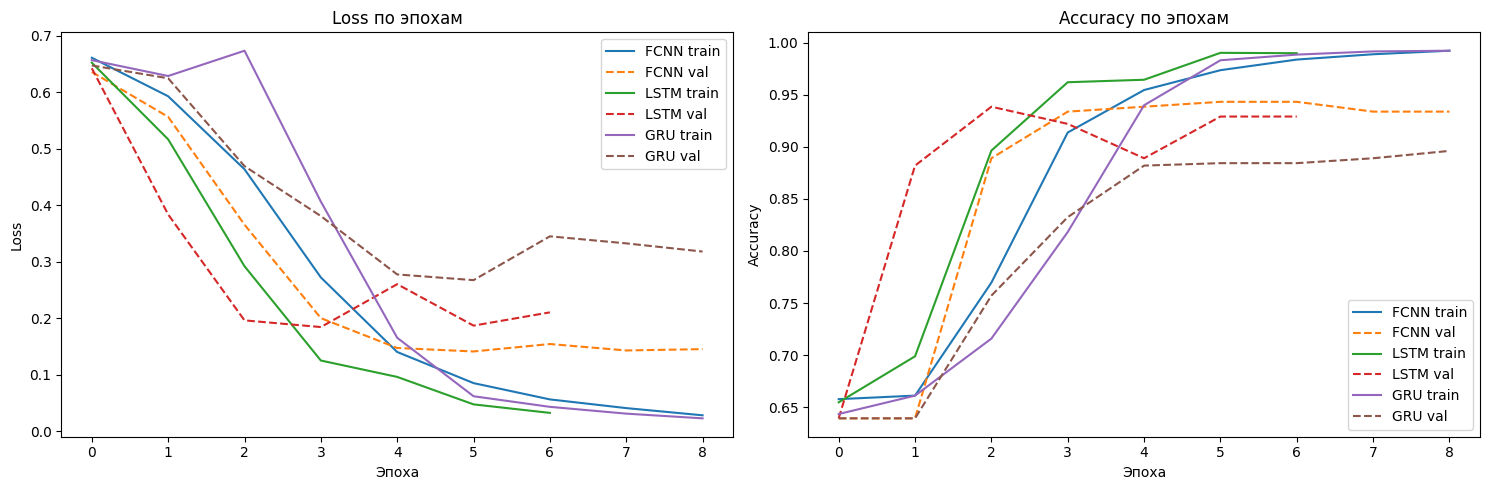

In [20]:
def plot_training_history(histories: Dict[str, tf.keras.callbacks.History]) -> None:
    """Рисует loss и accuracy для нескольких моделей."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for model_name, history in histories.items():
        axes[0].plot(history.history["loss"], label=f"{model_name} train")
        axes[0].plot(history.history["val_loss"], linestyle="--", label=f"{model_name} val")
        axes[1].plot(history.history["accuracy"], label=f"{model_name} train")
        axes[1].plot(history.history["val_accuracy"], linestyle="--", label=f"{model_name} val")
    axes[0].set_title("Loss по эпохам")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[1].set_title("Accuracy по эпохам")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_training_history({"FCNN": fcnn_history, "LSTM": lstm_history, "GRU": gru_history})

## 10. Оценка качества моделей

Для итогового сравнения полезно смотреть не только accuracy, но и precision/recall/F1. В этом блоке оцениваем baseline-модели на validation. Test-set оставляем для финальной проверки лучшей модели после Optuna.

In [21]:
def predict_labels(model: tf.keras.Model, dataset: tf.data.Dataset, num_classes: int) -> np.ndarray:
    """Получает предсказанные классы модели."""
    probabilities = model.predict(dataset, verbose=0)
    if num_classes == 2:
        return (probabilities.reshape(-1) >= 0.5).astype(int)
    return np.argmax(probabilities, axis=1).astype(int)


def evaluate_model(model: tf.keras.Model, dataset: tf.data.Dataset, y_true: np.ndarray, model_name: str, class_names: List[str]) -> Dict[str, float]:
    """Считает accuracy, macro precision, macro recall и macro F1."""
    y_pred = predict_labels(model, dataset, len(class_names))
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    return metrics

baseline_results = [
    evaluate_model(fcnn_model, val_ds, y_val, "FCNN", class_names),
    evaluate_model(lstm_model, val_ds, y_val, "LSTM", class_names),
    evaluate_model(gru_model, val_ds, y_val, "GRU", class_names),
]
pd.DataFrame(baseline_results).sort_values("f1_macro", ascending=False)

=== FCNN ===
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       153
           1       0.93      0.98      0.96       271

    accuracy                           0.94       424
   macro avg       0.95      0.93      0.94       424
weighted avg       0.94      0.94      0.94       424

=== LSTM ===
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       153
           1       0.91      0.97      0.94       271

    accuracy                           0.92       424
   macro avg       0.93      0.90      0.91       424
weighted avg       0.92      0.92      0.92       424

=== GRU ===
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       153
           1       0.90      0.92      0.91       271

    accuracy                           0.88       424
   macro avg       0.88      0.87      0.87       424
weighted avg       0.88      0.88   

,model,accuracy,precision_macro,recall_macro,f1_macro
0,FCNN,0.943396,0.948681,0.928683,0.937321
1,LSTM,0.922170,0.927185,0.903541,0.913390
2,GRU,0.884434,0.877722,0.869751,0.873434


## 11. Оптимизация гиперпараметров через Optuna

Гиперпараметры — это настройки, которые не обучаются градиентным спуском, но сильно влияют на качество: `model_type`, число слоев, число нейронов, `learning_rate`, `dropout`, `batch_norm`.

Мы максимизируем `macro F1` на validation:

$$
\theta^* = \arg\max_{\theta} F1_{macro}(f_{\theta}, D_{val}).
$$

In [22]:
def build_model_from_trial(trial: optuna.Trial) -> tf.keras.Model:
    """Создает модель по гиперпараметрам, предложенным Optuna."""
    model_type = trial.suggest_categorical("model_type", ["FCNN", "LSTM", "GRU"])
    embedding_dim = trial.suggest_categorical("embedding_dim", [64, 128, 256])
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5, step=0.1)
    batch_norm = trial.suggest_categorical("batch_norm", [False, True])
    if model_type == "FCNN":
        num_dense_layers = trial.suggest_int("num_dense_layers", 1, 4)
        return build_fcnn_model(len(tokenizer), MAX_LEN, NUM_CLASSES, embedding_dim, dense_units, num_dense_layers, learning_rate, dropout, batch_norm)
    rnn_units = trial.suggest_categorical("rnn_units", [32, 64, 128, 256])
    num_rnn_layers = trial.suggest_int("num_rnn_layers", 1, 3)
    bidirectional = trial.suggest_categorical("bidirectional", [True, False])
    return build_recurrent_model(model_type, len(tokenizer), MAX_LEN, NUM_CLASSES, embedding_dim, rnn_units, num_rnn_layers, dense_units, learning_rate, dropout, 0.0, batch_norm, bidirectional)


def objective(trial: optuna.Trial) -> float:
    """Целевая функция Optuna: обучает модель и возвращает macro F1 на validation."""
    tf.keras.backend.clear_session()
    model = build_model_from_trial(trial)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=make_callbacks(patience=3), verbose=0)
    y_pred = predict_labels(model, val_ds, NUM_CLASSES)
    score = f1_score(y_val, y_pred, average="macro", zero_division=0)
    trial.set_user_attr("best_val_loss", min(history.history["val_loss"]))
    trial.set_user_attr("epochs_trained", len(history.history["loss"]))
    del model, history
    gc.collect()
    tf.keras.backend.clear_session()
    return score

In [23]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True, group=True)
study = optuna.create_study(direction="maximize", sampler=sampler, study_name="russian_sentiment_lstm_gru_fcnn")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True, gc_after_trial=True)

[I 2026-05-19 14:05:29,896] A new study created in memory with name: russian_sentiment_lstm_gru_fcnn


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
[I 2026-05-19 14:07:07,857] Trial 0 finished with value: 0.8839310156036135 and parameters: {'model_type': 'LSTM', 'embedding_dim': 64, 'dense_units': 128, 'learning_rate': 0.0011114989443094978, 'dropout': 0.0, 'batch_norm': False, 'rnn_units': 256, 'num_rnn_layers': 2, 'bidirectional': True}. Best is trial 0 with value: 0.8839310156036135.


I0000 00:00:1779181629.299324   41848 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28938__.20
I0000 00:00:1779181630.857842   41855 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28938__.20


Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 6.
[I 2026-05-19 14:07:15,714] Trial 1 finished with value: 0.9312642974224112 and parameters: {'model_type': 'FCNN', 'embedding_dim': 256, 'dense_units': 256, 'learning_rate': 0.000117115099555241, 'dropout': 0.30000000000000004, 'batch_norm': False, 'num_dense_layers': 4}. Best is trial 1 with value: 0.9312642974224112.


...

Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
[I 2026-05-19 14:40:03,489] Trial 94 finished with value: 0.9374907857879994 and parameters: {'model_type': 'FCNN', 'embedding_dim': 128, 'dense_units': 64, 'learning_rate': 0.0010894738658227638, 'dropout': 0.5, 'batch_norm': False, 'num_dense_layers': 3}. Best is trial 23 with value: 0.9442212016838882.


I0000 00:00:1779183605.579623   41850 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_556296__.44
I0000 00:00:1779183606.983585   41850 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_556296__.44


Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
[I 2026-05-19 14:40:10,103] Trial 95 finished with value: 0.3899280575539568 and parameters: {'model_type': 'FCNN', 'embedding_dim': 64, 'dense_units': 64, 'learning_rate': 0.0021528366624372613, 'dropout': 0.5, 'batch_norm': True, 'num_dense_layers': 4}. Best is trial 23 with value: 0.9442212016838882.


I0000 00:00:1779183611.492794   41853 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_560409__.18
I0000 00:00:1779183612.592430   41846 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_560409__.18


Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
[I 2026-05-19 14:40:15,681] Trial 96 finished with value: 0.9304694285349869 and parameters: {'model_type': 'FCNN', 'embedding_dim': 128, 'dense_units': 256, 'learning_rate': 0.002402752617983292, 'dropout': 0.2, 'batch_norm': False, 'num_dense_layers': 3}. Best is trial 23 with value: 0.9442212016838882.
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
[I 2026-05-19 14:40:36,507] Trial 97 finished with value: 0.7478381537662266 and parameters: {'model_type': 'GRU', 'embedding_dim': 256, 'dense_units': 256, 'learning_rate': 0.0022647494464696732, 'dropout': 0.2, 'batch_norm': False, 'rnn_units': 64, 'num_rnn_layers': 2, 'bidirectional': False}. Best is trial 23 with value: 0.9442212016838882.
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.
[I 2026-05-19 14:41:16,573] Trial 98 finished with value: 0.9172178157413057 and parameters: {'mod

In [24]:
print("Лучший macro F1 на validation:", study.best_value)
print("Лучшие гиперпараметры:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Лучший macro F1 на validation: 0.9442212016838882
Лучшие гиперпараметры:
model_type: FCNN
embedding_dim: 64
dense_units: 64
learning_rate: 0.0011738315798529074
dropout: 0.5
batch_norm: False
num_dense_layers: 3


In [25]:
trials_df = study.trials_dataframe()
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_batch_norm,params_bidirectional,params_dense_units,params_dropout,params_embedding_dim,params_learning_rate,params_model_type,params_num_dense_layers,params_num_rnn_layers,params_rnn_units,user_attrs_best_val_loss,user_attrs_epochs_trained,state
23,23,0.944221,2026-05-19 14:15:52.123921,2026-05-19 14:16:01.337692,0 days 00:00:09.213771,False,NaN,64,0.5,64,0.001174,FCNN,3.0,NaN,NaN,0.160023,8,COMPLETE
61,61,0.944070,2026-05-19 14:29:25.430870,2026-05-19 14:29:30.536889,0 days 00:00:05.106019,False,NaN,64,0.2,64,0.001033,FCNN,3.0,NaN,NaN,0.139596,6,COMPLETE
22,22,0.943915,2026-05-19 14:15:46.524805,2026-05-19 14:15:51.886675,0 days 00:00:05.361870,False,NaN,64,0.5,128,0.000878,FCNN,3.0,NaN,NaN,0.160517,7,COMPLETE
11,11,0.943087,2026-05-19 14:12:21.774523,2026-05-19 14:12:26.286364,0 days 00:00:04.511841,False,NaN,128,0.0,128,0.002841,FCNN,4.0,NaN,NaN,0.148722,5,COMPLETE
40,40,0.942729,2026-05-19 14:23:27.868176,2026-05-19 14:23:33.375847,0 days 00:00:05.507671,False,NaN,256,0.1,128,0.001693,FCNN,4.0,NaN,NaN,0.152699,5,COMPLETE
2,2,0.942545,2026-05-19 14:07:15.937654,2026-05-19 14:07:20.770961,0 days 00:00:04.833307,False,NaN,128,0.1,128,0.002204,FCNN,3.0,NaN,NaN,0.149475,5,COMPLETE
21,21,0.940770,2026-05-19 14:15:41.026853,2026-05-19 14:15:46.302388,0 days 00:00:05.275535,False,NaN,64,0.3,128,0.000885,FCNN,3.0,NaN,NaN,0.140440,6,COMPLETE
17,17,0.939835,2026-05-19 14:14:54.882981,2026-05-19 14:15:01.883269,0 days 00:00:07.000288,False,NaN,64,0.2,128,0.001893,FCNN,3.0,NaN,NaN,0.159013,6,COMPLETE
28,28,0.938467,2026-05-19 14:19:37.167446,2026-05-19 14:19:42.041022,0 days 00:00:04.873576,False,NaN,64,0.5,128,0.001244,FCNN,2.0,NaN,NaN,0.139524,6,COMPLETE
91,91,0.938467,2026-05-19 14:39:39.384843,2026-05-19 14:39:44.469590,0 days 00:00:05.084747,False,NaN,256,0.0,256,0.001178,FCNN,3.0,NaN,NaN,0.176146,6,COMPLETE


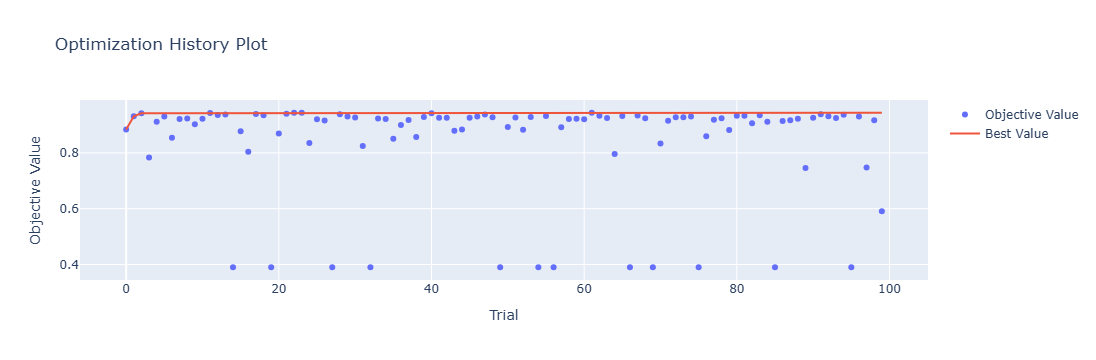

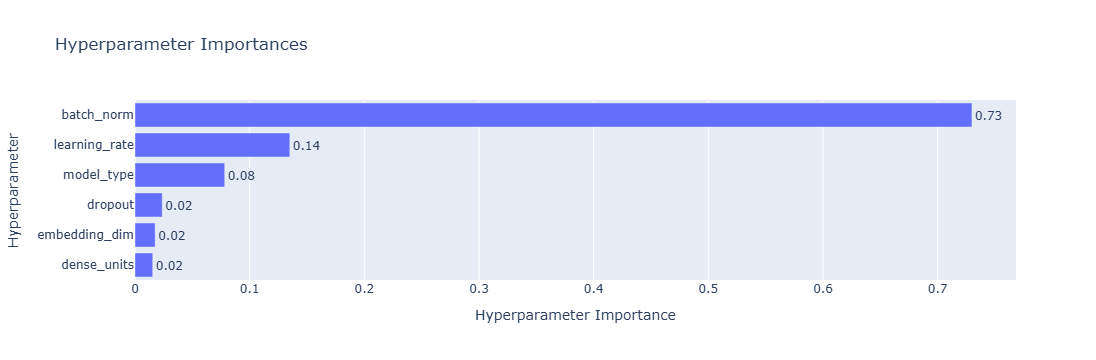

In [26]:
try:
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
    fig = optuna.visualization.plot_param_importances(study)
    fig.show()
except Exception as error:
    print("Визуализация Optuna недоступна:", error)

## 12. Обучение лучшей модели и финальная оценка на test

После подбора гиперпараметров нужно заново обучить лучшую архитектуру. В строгом исследовательском протоколе test-set используется только один раз — для финальной оценки.

In [27]:
def build_model_from_params(params: Dict) -> tf.keras.Model:
    """Создает модель из словаря лучших гиперпараметров Optuna."""
    model_type = params["model_type"]
    if model_type == "FCNN":
        return build_fcnn_model(len(tokenizer), MAX_LEN, NUM_CLASSES, params["embedding_dim"], params["dense_units"], params["num_dense_layers"], params["learning_rate"], params["dropout"], params["batch_norm"])
    return build_recurrent_model(model_type, len(tokenizer), MAX_LEN, NUM_CLASSES, params["embedding_dim"], params["rnn_units"], params["num_rnn_layers"], params["dense_units"], params["learning_rate"], params["dropout"], 0.0, params["batch_norm"], params["bidirectional"])

best_model = build_model_from_params(study.best_params)
best_model.summary()
best_history = train_model(best_model, train_ds, val_ds, EPOCHS)

Model: "FCNN_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 1024, 64)  │  5,364,992 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 1024)      │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling     │ (None, 64)        │          0 │ token_embedding[… │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ average_pooling[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_probabil… │ (None, 1)         │         65 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,377,537 (20.51 MB)

 Trainable params: 5,377,537 (20.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


I0000 00:00:1779183696.882442   41850 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_582298__.18


41/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6158 - loss: 0.6803

I0000 00:00:1779183697.875261   41845 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_582298__.18


46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.6542 - loss: 0.6548 - val_accuracy: 0.6392 - val_loss: 0.6167
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7039 - loss: 0.4864 - val_accuracy: 0.9316 - val_loss: 0.3188
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9367 - loss: 0.2164 - val_accuracy: 0.9340 - val_loss: 0.1998
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9721 - loss: 0.0938 - val_accuracy: 0.9316 - val_loss: 0.1695
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9864 - loss: 0.0510 - val_accuracy: 0.9458 - val_loss: 0.1764
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9898 - loss: 0.0371 - val_accuracy: 0.9387 - val_loss: 0.2046
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9922 - loss: 0.0330 - val_accuracy: 0.9340 - val_loss: 0.2293
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


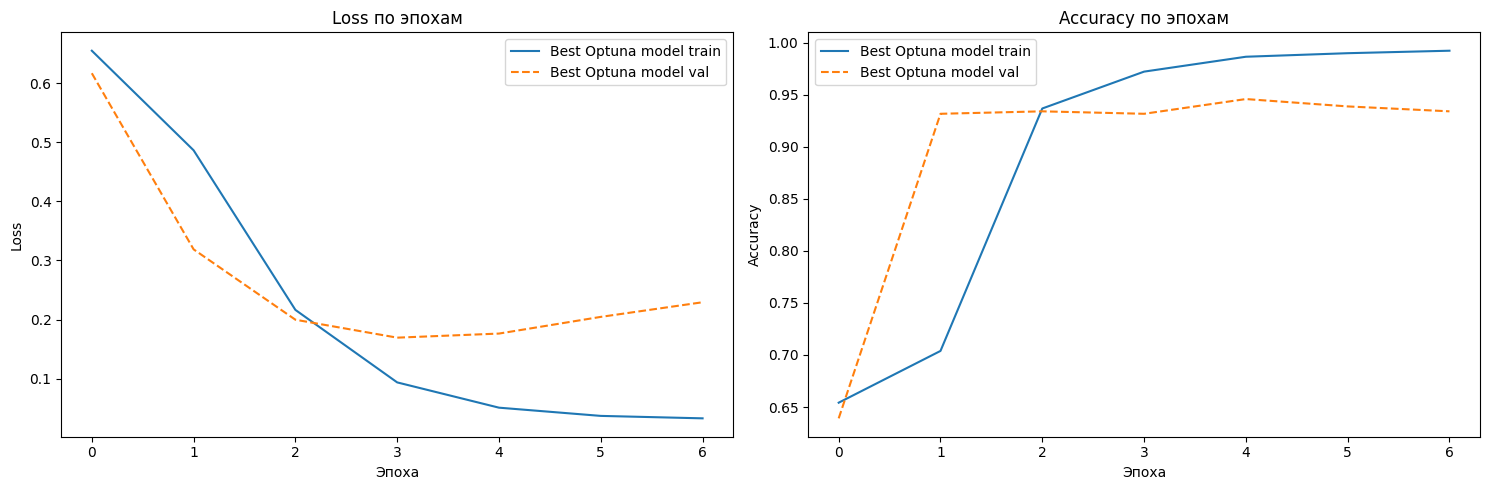

In [28]:
plot_training_history({"Best Optuna model": best_history})

In [29]:
test_metrics = evaluate_model(best_model, test_ds, y_test, "Best Optuna model", class_names)
pd.DataFrame([test_metrics])

I0000 00:00:1779183700.497486   41845 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779183700.617130  115739 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1779183700.719827  115751 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1779183700.748849  115747 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 68 bytes spill stores, 68 bytes spill loads

I0000 00:00:1779183700.881408  115740 subprocess_compilation.cc:348] ptxas warning : Registers are spil

=== Best Optuna model ===
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       285
           1       0.95      0.94      0.94       582

    accuracy                           0.92       867
   macro avg       0.91      0.92      0.91       867
weighted avg       0.92      0.92      0.92       867



,model,accuracy,precision_macro,recall_macro,f1_macro
0,Best Optuna model,0.923875,0.911599,0.917336,0.91436


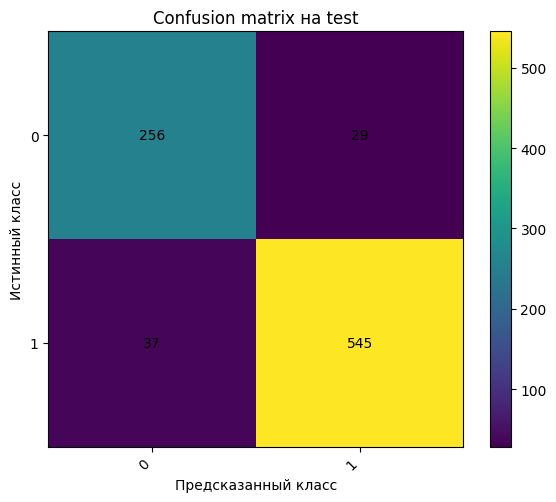

In [30]:
y_test_pred = predict_labels(best_model, test_ds, NUM_CLASSES)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion matrix на test")
plt.colorbar()
plt.xticks(np.arange(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.yticks(np.arange(NUM_CLASSES), class_names)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

## 13. Интерпретация ошибок

Финальный академический шаг — посмотреть не только числа, но и конкретные ошибки. Это помогает понять природу задачи: сарказм, короткие неоднозначные фразы, смешанную эмоциональную окраску, незнакомые слова или слишком сильное обрезание длинных текстов.

In [31]:
def show_errors(frame: pd.DataFrame, y_true: np.ndarray, y_pred: np.ndarray, n: int = 10) -> pd.DataFrame:
    """Возвращает примеры ошибочных предсказаний."""
    error_mask = y_true != y_pred
    errors = frame.iloc[np.where(error_mask)[0]].copy()
    errors["true_label"] = label_encoder.inverse_transform(y_true[error_mask])
    errors["predicted_label"] = label_encoder.inverse_transform(y_pred[error_mask])
    return errors[["text", "true_label", "predicted_label", "token_count"]].head(n)

show_errors(test_df, y_test, y_test_pred, n=10)

,text,true_label,predicted_label,token_count
21,Строительство металлургического завода в ЮКО з...,0,1,241
26,Депутат Мажилиса РК Сакен Утебаев пожаловался ...,0,1,187
36,Казахстан разработает Дорожную карту по развит...,0,1,370
38,"По итогам минувшего , 2016 - го года официальн...",1,0,350
39,Производство автомобилей в Казахстане за 10 ме...,0,1,382
48,Департамент Комитета по регулированию естестве...,1,0,246
59,Наполовину сократились продажи автопрома РК в ...,0,1,288
70,Девальвация тенге снизила объем накопленных ро...,0,1,569
89,Итоги 2016 года Статистика регистраций За 2016...,0,1,1062
91,"27 - летний Куаныш Нургалымов , возможно , пре...",1,0,307


## 14. Выводы и идеи для развития

В этом блокноте мы прошли полный цикл исследования:

1. Загрузили русскоязычный датасет сентимента.
2. Провели первичный анализ данных и классов.
3. Токенизировали текст с помощью `cointegrated/rubert-tiny2`.
4. Построили три архитектуры: FCNN, LSTM и GRU.
5. Сравнили baseline-модели.
6. Подобрали гиперпараметры через Optuna.
7. Оценили лучшую модель на test-set.
8. Посмотрели конкретные ошибки классификации.

Что можно улучшить дальше: использовать предобученный трансформер целиком, добавить class weights при дисбалансе, сравнить разные `MAX_LEN`, провести k-fold cross-validation и отдельно анализировать ошибки по длине текста.